In [1]:
# =========================================================
# Quantitative Error Case Study
#
# Purpose:
# Quantitatively verify the continuum hypothesis:
# Depression ↔ Suicidal overlap is not random error,
# but reflects real severity progression.
#
# Core Questions:
# 1. How many Depression samples are predicted as Suicidal?
# 2. How many Suicidal samples are predicted as Depression?
# 3. Are severe-Depression samples more likely to be
#    predicted as Suicidal?
# 4. Are low-risk Suicidal samples more likely to be
#    predicted as Depression?
#
# Output:
# 1. quantitative statistics table
# 2. overlap analysis
# 3. hard case examples
# 4. saved csv + txt report
#
# Required:
# best_dual_regression.pt
#
# =========================================================

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix
import os
import random
from tqdm import tqdm
import warnings

warnings.filterwarnings("ignore")


# =========================================================
# Random Seed
# =========================================================

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)


# =========================================================
# Device
# =========================================================

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)


# =========================================================
# Path Config
# =========================================================

LOCAL_MODEL_DIR = "./hf_models"
MODEL_PATH = os.path.join(LOCAL_MODEL_DIR, "roberta-base")
CHECKPOINT_PATH = "best_dual_regression.pt"


# =========================================================
# Load Dataset
# =========================================================

print("\nLoading dataset...")

df = pd.read_csv("mental_heath_unbanlanced.csv")

df = df.dropna(subset=["text", "status"])
df["text"] = df["text"].astype(str)

label_encoder = LabelEncoder()
df["label_encoded"] = label_encoder.fit_transform(df["status"])

print("\nLabel Mapping:")
for i, label in enumerate(label_encoder.classes_):
    print(f"{i} -> {label}")

"""
Confirmed:
0 -> Anxiety
1 -> Depression
2 -> Normal
3 -> Suicidal
"""


# =========================================================
# Split Dataset
# =========================================================

train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df["text"].tolist(),
    df["label_encoded"].tolist(),
    test_size=0.3,
    random_state=42,
    stratify=df["label_encoded"]
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts,
    temp_labels,
    test_size=0.5,
    random_state=42,
    stratify=temp_labels
)

print(f"\nTest size: {len(test_texts)}")


# =========================================================
# Dataset Class
# =========================================================

class RiskDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=96):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(),
            "attention_mask": encoding["attention_mask"].squeeze(),
            "label": torch.tensor(self.labels[idx], dtype=torch.long),
            "text": self.texts[idx]
        }


# =========================================================
# Model
# =========================================================

class DualRegressionModel(nn.Module):
    def __init__(self, model_path):
        super().__init__()

        self.encoder = AutoModel.from_pretrained(
            model_path,
            local_files_only=True
        )

        hidden = self.encoder.config.hidden_size

        self.dropout = nn.Dropout(0.1)

        self.dep_head = nn.Linear(hidden, 1)
        self.sui_head = nn.Linear(hidden, 1)

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        cls = outputs.last_hidden_state[:, 0, :]
        cls = self.dropout(cls)

        dep_score = torch.sigmoid(
            self.dep_head(cls)
        ).squeeze(-1)

        sui_score = torch.sigmoid(
            self.sui_head(cls)
        ).squeeze(-1)

        return {
            "dep_score": dep_score,
            "sui_score": sui_score
        }


# =========================================================
# Mapping Rule
# =========================================================

def map_scores_to_class(dep_score, sui_score):
    """
    2 -> Normal
    0 -> Anxiety
    1 -> Depression
    3 -> Suicidal
    """

    if sui_score >= 0.70:
        return 3

    elif dep_score >= 0.68:
        return 1

    elif dep_score >= 0.30:
        return 0

    else:
        return 2


# =========================================================
# Load Model
# =========================================================

print("\nLoading checkpoint...")

model = DualRegressionModel(MODEL_PATH).to(DEVICE)

model.load_state_dict(
    torch.load(
        CHECKPOINT_PATH,
        map_location=DEVICE
    )
)

model.eval()

print("Checkpoint loaded successfully.")


# =========================================================
# Tokenizer + Loader
# =========================================================

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_PATH,
    local_files_only=True
)

test_dataset = RiskDataset(
    test_texts,
    test_labels,
    tokenizer
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)


# =========================================================
# Inference
# =========================================================

print("\nRunning inference...")

records = []

with torch.no_grad():
    for batch in tqdm(test_loader):

        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels = batch["label"].numpy()
        texts = batch["text"]

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        dep_scores = outputs["dep_score"].cpu().numpy()
        sui_scores = outputs["sui_score"].cpu().numpy()

        for text, true_label, dep, sui in zip(
            texts,
            labels,
            dep_scores,
            sui_scores
        ):
            pred = map_scores_to_class(dep, sui)

            records.append({
                "text": text,
                "true_label": true_label,
                "pred_label": pred,
                "dep_score": float(dep),
                "sui_score": float(sui)
            })


result_df = pd.DataFrame(records)


# =========================================================
# Key Overlap Analysis
# =========================================================

print("\n====================================================")
print("Quantitative Error Case Study")
print("====================================================")

# Depression -> Suicidal
dep_to_sui = result_df[
    (result_df["true_label"] == 1) &
    (result_df["pred_label"] == 3)
]

# Suicidal -> Depression
sui_to_dep = result_df[
    (result_df["true_label"] == 3) &
    (result_df["pred_label"] == 1)
]

total_dep = len(result_df[result_df["true_label"] == 1])
total_sui = len(result_df[result_df["true_label"] == 3])

dep_to_sui_ratio = len(dep_to_sui) / total_dep
sui_to_dep_ratio = len(sui_to_dep) / total_sui

print(f"Depression → Suicidal: {len(dep_to_sui)} / {total_dep}")
print(f"Ratio: {dep_to_sui_ratio:.4f}")

print()

print(f"Suicidal → Depression: {len(sui_to_dep)} / {total_sui}")
print(f"Ratio: {sui_to_dep_ratio:.4f}")


# =========================================================
# Severity Analysis
# =========================================================

print("\n====================================================")
print("Severity Analysis")
print("====================================================")

# severe depression (high dep score)
severe_dep = result_df[
    (result_df["true_label"] == 1) &
    (result_df["dep_score"] >= 0.80)
]

severe_dep_to_sui = severe_dep[
    severe_dep["pred_label"] == 3
]

if len(severe_dep) > 0:
    severe_ratio = len(severe_dep_to_sui) / len(severe_dep)
else:
    severe_ratio = 0

print(f"Severe Depression Samples: {len(severe_dep)}")
print(f"Predicted as Suicidal: {len(severe_dep_to_sui)}")
print(f"Ratio: {severe_ratio:.4f}")


# low-risk suicidal
low_sui = result_df[
    (result_df["true_label"] == 3) &
    (result_df["sui_score"] < 0.75)
]

low_sui_to_dep = low_sui[
    low_sui["pred_label"] == 1
]

if len(low_sui) > 0:
    low_ratio = len(low_sui_to_dep) / len(low_sui)
else:
    low_ratio = 0

print()

print(f"Low-confidence Suicidal Samples: {len(low_sui)}")
print(f"Predicted as Depression: {len(low_sui_to_dep)}")
print(f"Ratio: {low_ratio:.4f}")


# =========================================================
# Save Hard Cases
# =========================================================

print("\nSaving hard cases...")

hard_cases = pd.concat([
    dep_to_sui.head(100),
    sui_to_dep.head(100)
])

hard_cases.to_csv(
    "hard_case_examples.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Saved: hard_case_examples.csv")


# =========================================================
# Save Full Report
# =========================================================

save_path = "quantitative_case_study_report.txt"

with open(save_path, "w", encoding="utf-8") as f:
    f.write("Quantitative Error Case Study\n")
    f.write("=" * 60 + "\n\n")

    f.write(
        f"Depression → Suicidal: "
        f"{len(dep_to_sui)} / {total_dep}\n"
    )
    f.write(
        f"Ratio: {dep_to_sui_ratio:.4f}\n\n"
    )

    f.write(
        f"Suicidal → Depression: "
        f"{len(sui_to_dep)} / {total_sui}\n"
    )
    f.write(
        f"Ratio: {sui_to_dep_ratio:.4f}\n\n"
    )

    f.write(
        f"Severe Depression → Suicidal Ratio: "
        f"{severe_ratio:.4f}\n"
    )

    f.write(
        f"Low-confidence Suicidal → Depression Ratio: "
        f"{low_ratio:.4f}\n\n"
    )

    f.write(
        "Interpretation:\n"
        "If severe depression is more likely to be "
        "predicted as suicidal, and low-confidence "
        "suicidal cases are more likely to be predicted "
        "as depression, this strongly supports the "
        "continuum hypothesis rather than simple "
        "classification error.\n"
    )

print(f"Saved: {save_path}")


Using device: cuda

Loading dataset...

Label Mapping:
0 -> Anxiety
1 -> Depression
2 -> Normal
3 -> Suicidal

Test size: 7442

Loading checkpoint...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: ./hf_models\roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Checkpoint loaded successfully.

Running inference...


100%|██████████████████████████████████████████████████████████████████████████████| 233/233 [00:32<00:00,  7.16it/s]


Quantitative Error Case Study
Depression → Suicidal: 372 / 2176
Ratio: 0.1710

Suicidal → Depression: 289 / 1682
Ratio: 0.1718

Severity Analysis
Severe Depression Samples: 526
Predicted as Suicidal: 368
Ratio: 0.6996

Low-confidence Suicidal Samples: 437
Predicted as Depression: 289
Ratio: 0.6613

Saving hard cases...
Saved: hard_case_examples.csv
Saved: quantitative_case_study_report.txt



Generating Figure 6...


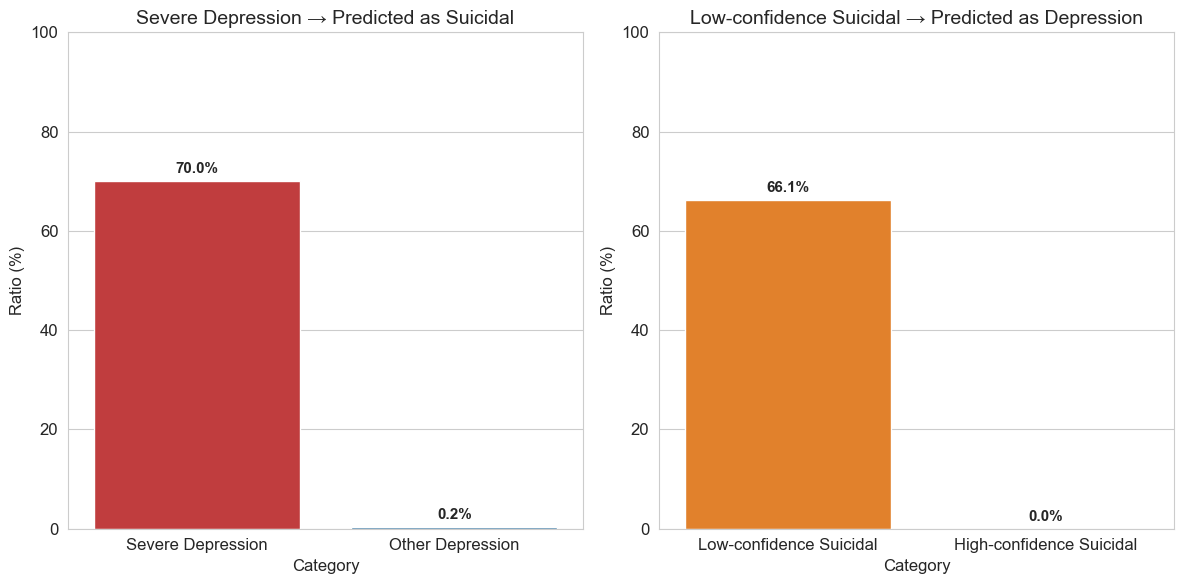

In [2]:

# =========================================================
# Figure 8: Severe Depression → Suicidal Transition Analysis
# =========================================================
print("\nGenerating Figure 6...")

import matplotlib.pyplot as plt
import seaborn as sns

# 设置美观风格
sns.set_style("whitegrid")
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['figure.figsize'] = (10, 7)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# 左侧：Severe Depression → Suicidal
severe_data = {
    'Category': ['Severe Depression', 'Other Depression'],
    'Predicted as Suicidal (%)': [severe_ratio * 100, 
                                  (len(dep_to_sui) - len(severe_dep_to_sui)) / (total_dep - len(severe_dep)) * 100 
                                  if (total_dep - len(severe_dep)) > 0 else 0]
}

sns.barplot(
    x='Category', 
    y='Predicted as Suicidal (%)', 
    data=pd.DataFrame(severe_data),
    ax=axes[0],
    palette=['#d62728', '#1f77b4']
)

axes[0].set_title('Severe Depression → Predicted as Suicidal')
axes[0].set_ylabel('Ratio (%)')
axes[0].set_ylim(0, 100)

# 在柱子上显示数值
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.1f}%', 
                     (p.get_x() + p.get_width()/2., p.get_height() + 1),
                     ha='center', va='bottom', fontsize=11, fontweight='bold')

# 右侧：Low-confidence Suicidal → Depression
low_data = {
    'Category': ['Low-confidence Suicidal', 'High-confidence Suicidal'],
    'Predicted as Depression (%)': [low_ratio * 100,
                                    (len(sui_to_dep) - len(low_sui_to_dep)) / (total_sui - len(low_sui)) * 100 
                                    if (total_sui - len(low_sui)) > 0 else 0]
}

sns.barplot(
    x='Category', 
    y='Predicted as Depression (%)', 
    data=pd.DataFrame(low_data),
    ax=axes[1],
    palette=['#ff7f0e', '#2ca02c']
)

axes[1].set_title('Low-confidence Suicidal → Predicted as Depression')
axes[1].set_ylabel('Ratio (%)')
axes[1].set_ylim(0, 100)

for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}%', 
                     (p.get_x() + p.get_width()/2., p.get_height() + 1),
                     ha='center', va='bottom', fontsize=11, fontweight='bold')

#plt.suptitle('Figure 8: Severity-Dependent Transition Analysis\nSupporting the Depression-Suicidal Continuum Hypothesis', 
#             fontsize=16, y=1.02)

plt.tight_layout()
plt.savefig('Figure_8_Transition_Analysis.png', dpi=300, bbox_inches='tight')
plt.show()

